In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 500

daily_returns = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=n
)

prices = (
    100 *
    np.cumprod(
        1 + daily_returns
    )
)

volume = np.random.randint(
    1000,
    5000,
    size=n
)

df = pd.DataFrame()

df["Close"] = prices
df["Volume"] = volume

df.head()

,Close,Volume
0,101.093428,2305
1,100.914969,4391
2,102.323114,2761
3,105.542260,4514
4,105.153541,2975


In [ ]:
df["Return"] = (
    df["Close"]
    .pct_change()
)

In [ ]:
df["MA10"] = (
    df["Close"]
    .rolling(10)
    .mean()
)

df["Signal"] = np.where(
    df["Close"]
    >
    df["MA10"],
    1,
    0
)

In [ ]:
df["Baseline_Return"] = (
    df["Signal"]
    .shift(1)
    *
    df["Return"]
)

df["Baseline_Equity"] = (
    1 +
    df["Baseline_Return"]
).cumprod()

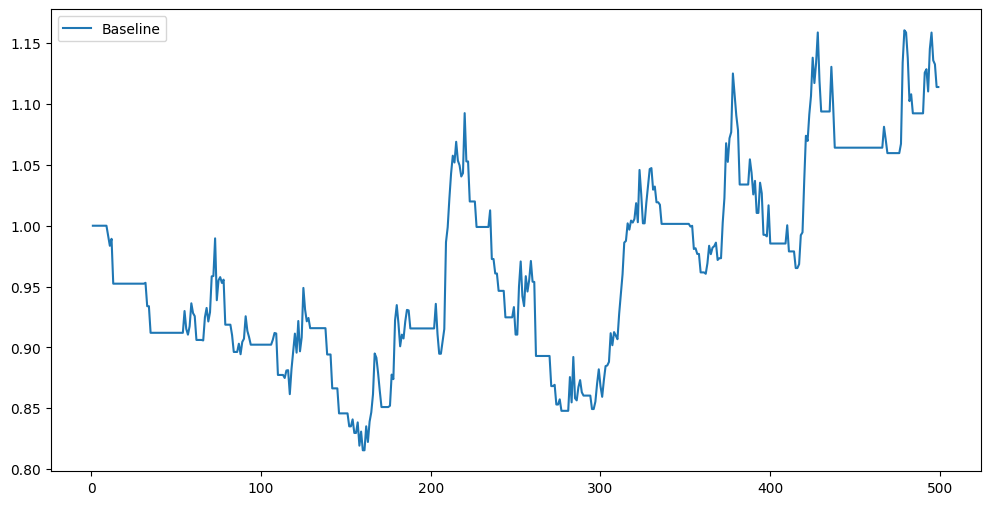

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Baseline_Equity"],
    label="Baseline"
)

plt.legend()

plt.show()

In [ ]:
df["Trade"] = (
    df["Signal"]
    !=
    df["Signal"].shift(1)
).astype(int)

In [ ]:
cost_per_trade = 0.001

df["Cost"] = (
    df["Trade"]
    *
    cost_per_trade
)

In [ ]:
df["Cost_Return"] = (
    df["Baseline_Return"]
    -
    df["Cost"]
)

In [ ]:
df["Cost_Equity"] = (
    1 +
    df["Cost_Return"]
).cumprod()

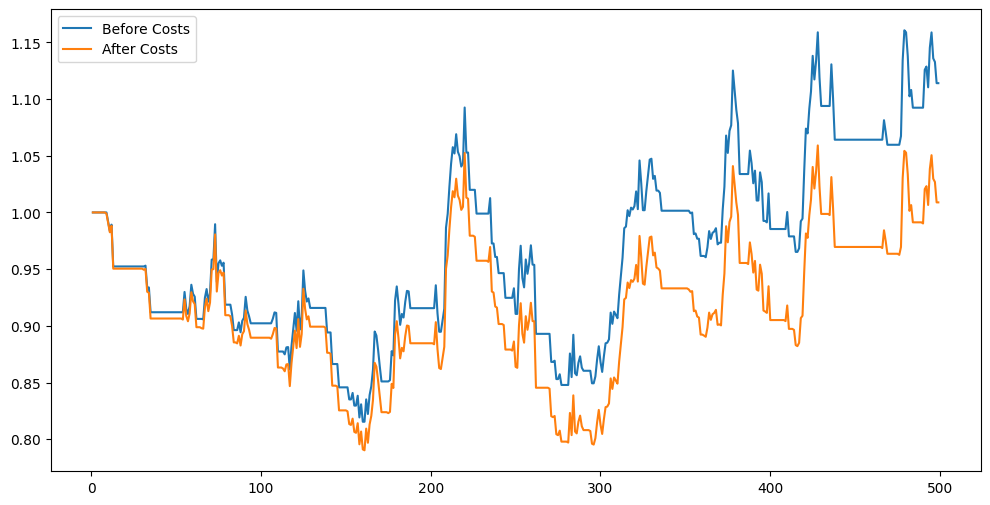

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Baseline_Equity"],
    label="Before Costs"
)

plt.plot(
    df["Cost_Equity"],
    label="After Costs"
)

plt.legend()

plt.show()

In [ ]:
slippage = 0.0005

df["Slippage_Return"] = (
    df["Cost_Return"]
    -
    (
        df["Trade"]
        *
        slippage
    )
)

In [ ]:
df["Slippage_Equity"] = (
    1 +
    df["Slippage_Return"]
).cumprod()

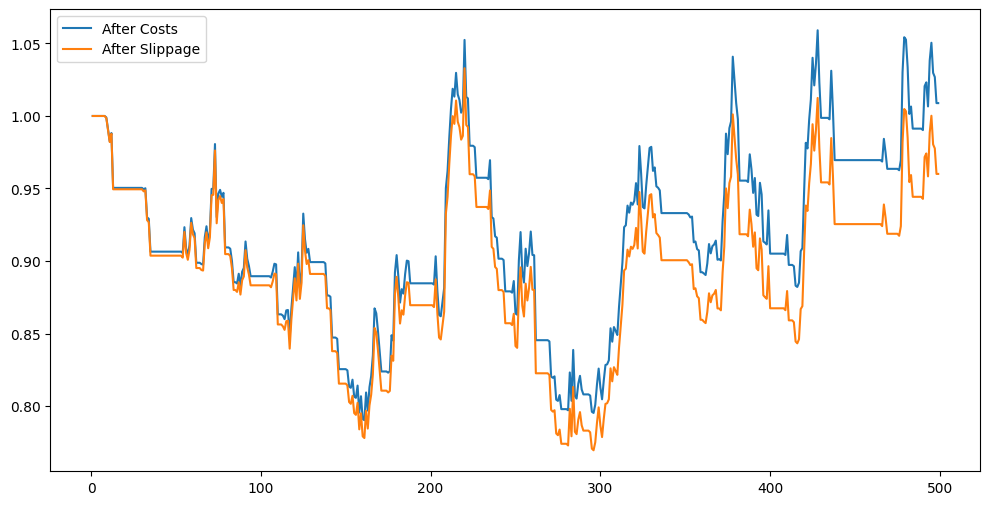

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Cost_Equity"],
    label="After Costs"
)

plt.plot(
    df["Slippage_Equity"],
    label="After Slippage"
)

plt.legend()

plt.show()

In [ ]:
df["AvgVolume"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)

In [ ]:
df["Liquid"] = np.where(
    df["Volume"]
    >
    df["AvgVolume"],
    1,
    0
)

In [ ]:
df["Liquidity_Return"] = (
    df["Slippage_Return"]
    *
    df["Liquid"]
)

In [ ]:
df["Liquidity_Equity"] = (
    1 +
    df["Liquidity_Return"]
).cumprod()

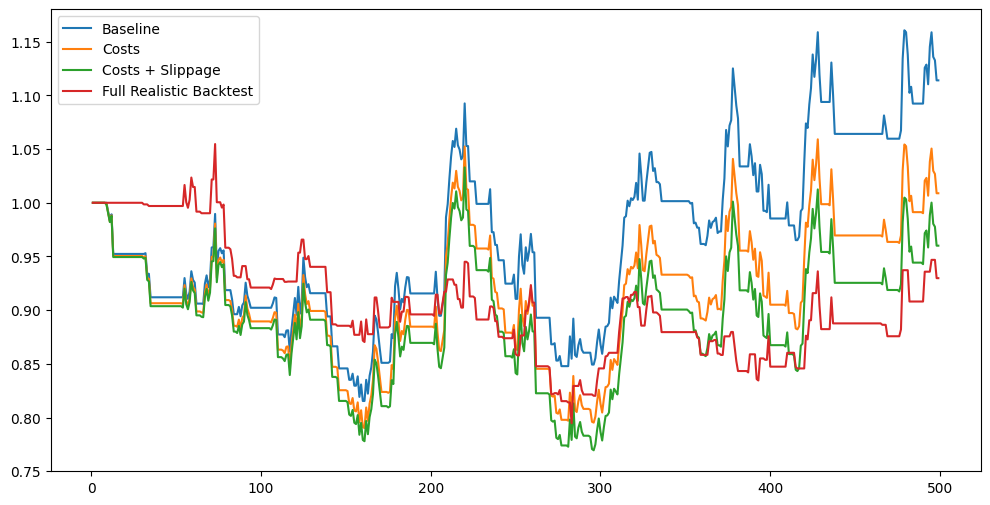

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Baseline_Equity"],
    label="Baseline"
)

plt.plot(
    df["Cost_Equity"],
    label="Costs"
)

plt.plot(
    df["Slippage_Equity"],
    label="Costs + Slippage"
)

plt.plot(
    df["Liquidity_Equity"],
    label="Full Realistic Backtest"
)

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    "Version": [
        "Baseline",
        "Costs",
        "Costs+Slippage",
        "Full Realistic"
    ],
    "Final Value": [
        df["Baseline_Equity"].iloc[-1],
        df["Cost_Equity"].iloc[-1],
        df["Slippage_Equity"].iloc[-1],
        df["Liquidity_Equity"].iloc[-1]
    ]
})

print(results)

          Version  Final Value
0        Baseline     1.114014
1           Costs     1.008875
2  Costs+Slippage     0.960051
3  Full Realistic     0.929795


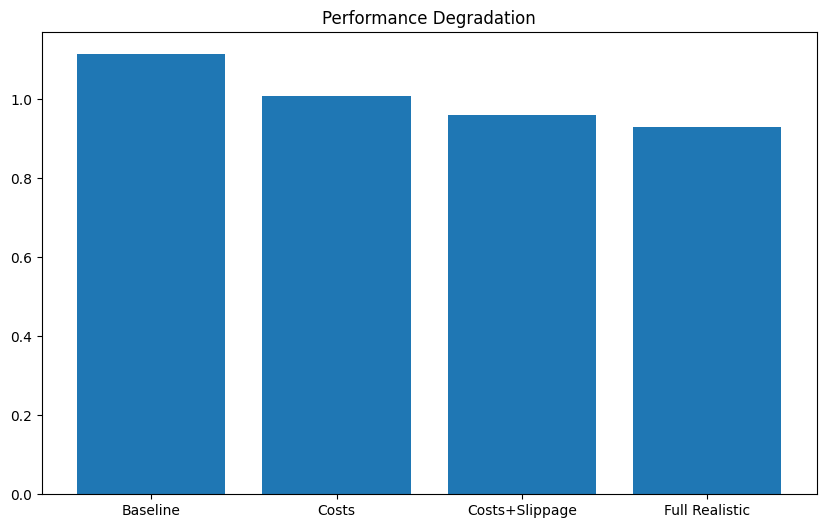

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    results["Version"],
    results["Final Value"]
)

plt.title(
    "Performance Degradation"
)

plt.show()